## Exploratory Data Analysis (EDA)

This EDA focuses on insights relevant to:
1. Predicting Temperature (a regression task).
2. Categorising the combined “Plant Type-Stage” (a classification task).
This notebook will identify important patterns, relationships and also potential issues (e.g. missing data, outliers) that will shape the modelling for the ML pipeline later on.

## 1. Retrieve Data from DB

The first step is to import the data from agri.db. We will use the Pandas library to read the data into a DataFrame.

In [1]:
# Copying agri.db to use the relative path `data/calls.db`
import shutil

shutil.copy('data/agri.db', 'data/calls.db')

'data/calls.db'

In [2]:
# Identify the tables in the database
import sqlite3
import pandas as pd

conn = sqlite3.connect('data/calls.db')

cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables in the database:", cursor.fetchall())

conn.close()

Tables in the database: [('farm_data',)]


In [3]:
# Display the contents of the 'farm_data' table
from IPython.display import display

conn = sqlite3.connect('data/calls.db')

cursor = conn.cursor()

df = pd.read_sql_query("SELECT * FROM farm_data", conn)

display(df)

conn.close()

,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,Herbs,Vine Crops,Maturity,23.34,NaN,454.0,937,1.82,4,161,64,201,6.1,28.150346
1,Zone_G,Herbs,VINE CROPS,Vegetative,-24.16,63.14,441.0,938,2.13,6,161,53,None,6.5,31.000000
2,Zone_F,Herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228,79,292,6.4,26.000000
3,Zone_G,Herbs,fruiting vegetables,Vegetative,22.61,NaN,651.0,1346,1.96,6,None,53 ppm,289,6.6,NaN
4,Zone_B,Vine Crops,LEAFY GREENS,seedling,22.88,NaN,144.0,812,2.76,5,61,19,168,5.5,28.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57484,Zone_C,Vine Crops,Fruiting Vegetables,Maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57485,Zone_C,Vine Crops,Fruiting Vegetables,Maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57486,Zone_E,Herbs,VINE CROPS,Seedling,24.85,NaN,203.0,816,0.98,7,121,41,114,4.9,21.000000
57487,Zone_G,Fruiting Vegetables,VINE CROPS,Vegetative,23.45,64.89,502.0,911,2.27,5,190,57,196,5.9,35.000000


## 2. Data Cleaning

The imported data has a lot of unclean data with no standardisation. The next step is to clean the data. This includes handling missing values, converting data types and removing duplicates.

In [4]:
# Fill empty cells with NaN
cols = df.columns
df[cols] = df[cols].fillna('NaN')

# display(df)

In [5]:
# Convert all object columns to lowercase
object_cols = [
    'Previous Cycle Plant Type',
    'Plant Type',
    'Plant Stage'
]

for col in object_cols:
    df[col] = df[col].str.lower()

# display(df)

In [6]:
# Convert numeric columns to fully numeric values
numeric_cols = [
    'Temperature Sensor (°C)',
    'Humidity Sensor (%)',
    'Light Intensity Sensor (lux)',
    'CO2 Sensor (ppm)',
    'EC Sensor (dS/m)',
    'O2 Sensor (ppm)',
    'Nutrient N Sensor (ppm)',
    'Nutrient P Sensor (ppm)',
    'Nutrient K Sensor (ppm)',
    'pH Sensor',
    'Water Level Sensor (mm)'
]

for col in numeric_cols:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# display(df)


In [7]:
# Remove duplicates
df = df.drop_duplicates()

display(df)

,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,herbs,vine crops,maturity,23.34,NaN,454.0,937,1.82,4,161.0,64.0,201.0,6.1,28.150346
1,Zone_G,herbs,vine crops,vegetative,-24.16,63.14,441.0,938,2.13,6,161.0,53.0,NaN,6.5,31.000000
2,Zone_F,herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228.0,79.0,292.0,6.4,26.000000
3,Zone_G,herbs,fruiting vegetables,vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53.0,289.0,6.6,NaN
4,Zone_B,vine crops,leafy greens,seedling,22.88,NaN,144.0,812,2.76,5,61.0,19.0,168.0,5.5,28.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57483,Zone_G,herbs,herbs,seedling,25.79,NaN,262.0,1115,1.36,6,147.0,34.0,186.0,6.3,27.000000
57484,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150.0,61.0,210.0,6.4,NaN
57486,Zone_E,herbs,vine crops,seedling,24.85,NaN,203.0,816,0.98,7,121.0,41.0,114.0,4.9,21.000000
57487,Zone_G,fruiting vegetables,vine crops,vegetative,23.45,64.89,502.0,911,2.27,5,190.0,57.0,196.0,5.9,35.000000


## 3. Data Pre-processing

After cleaning the data, we will pre-process the data to make the data logical and easier to work with.

### 3.1. Dealing with illogical negative values

In [8]:
'''
We observe negative values in some columns.
Some of these values are illogical so let's look into them.
'''
print("Columns with negative values:")
for col in numeric_cols:
    if df[col].lt(0).any():
        print(col)

Columns with negative values:
Temperature Sensor (°C)
Light Intensity Sensor (lux)
EC Sensor (dS/m)


In [9]:
'''
Upon researching on what values these sensors take, we find that these negative values in all 3 columns are illogical.
1. Temperature Sensor (°C) can have negative values, but in the context of a farm, it's unlikely as the plants will all die.
2. Light Intensity Sensor (lux) measure the intensity of light and these values are always zero or positive.
3. EC Sensor (dS/m) measures of the ability to conduct electricity and these values also cannot be negative.
As such, we can consider to drop these rows.
'''

print("Number of rows with negative values:", df[numeric_cols].lt(0).any(axis=1).sum())
print(f"Percentage of rows with negative values: {df[numeric_cols].lt(0).any(axis=1).sum() / len(df) * 100}%")

Number of rows with negative values: 2238
Percentage of rows with negative values: 4.476%


In [10]:
'''
Since the percentage of rows with negative values is low, we can afford to drop these rows without losing much information.
'''

df = df[~df[numeric_cols].lt(0).any(axis=1)]

### 3.2. Dealing with missing values

In [11]:
'''
Missing values can reduce our sample size, which may compromise the accuracy and reliability of our analysis and introduce bias if not handled properly.
It is important to identify and handle missing values in a way that does not introduce bias or affect the distribution of the data.
'''

print("% of NaN values per column: (before imputation or removal)")
print(df.isna().sum() / df.shape[0] * 100)

% of NaN values per column: (before imputation or removal)
System Location Code             0.000000
Previous Cycle Plant Type        0.000000
Plant Type                       0.000000
Plant Stage                      0.000000
Temperature Sensor (°C)         15.518613
Humidity Sensor (%)             67.476236
Light Intensity Sensor (lux)     7.595997
CO2 Sensor (ppm)                 0.000000
EC Sensor (dS/m)                 0.000000
O2 Sensor (ppm)                  0.000000
Nutrient N Sensor (ppm)         17.386207
Nutrient P Sensor (ppm)          9.932582
Nutrient K Sensor (ppm)          6.448641
pH Sensor                        0.000000
Water Level Sensor (mm)         15.026590
dtype: float64


In [12]:
'''
First, we deal with the columns that have a high percentage of NaN values.
We observe that the column 'Humidity Sensor (%)' has a high percentage (>50%) of NaN values.
We will remove it as it will complicate the analysis and make it harder to intrepret the model.
'''

df = df.drop(columns=['Humidity Sensor (%)'])
numeric_cols.remove('Humidity Sensor (%)')

Columns with NaN values: Index(['Temperature Sensor (°C)', 'Light Intensity Sensor (lux)',
       'Nutrient N Sensor (ppm)', 'Nutrient P Sensor (ppm)',
       'Nutrient K Sensor (ppm)', 'Water Level Sensor (mm)'],
      dtype='object')


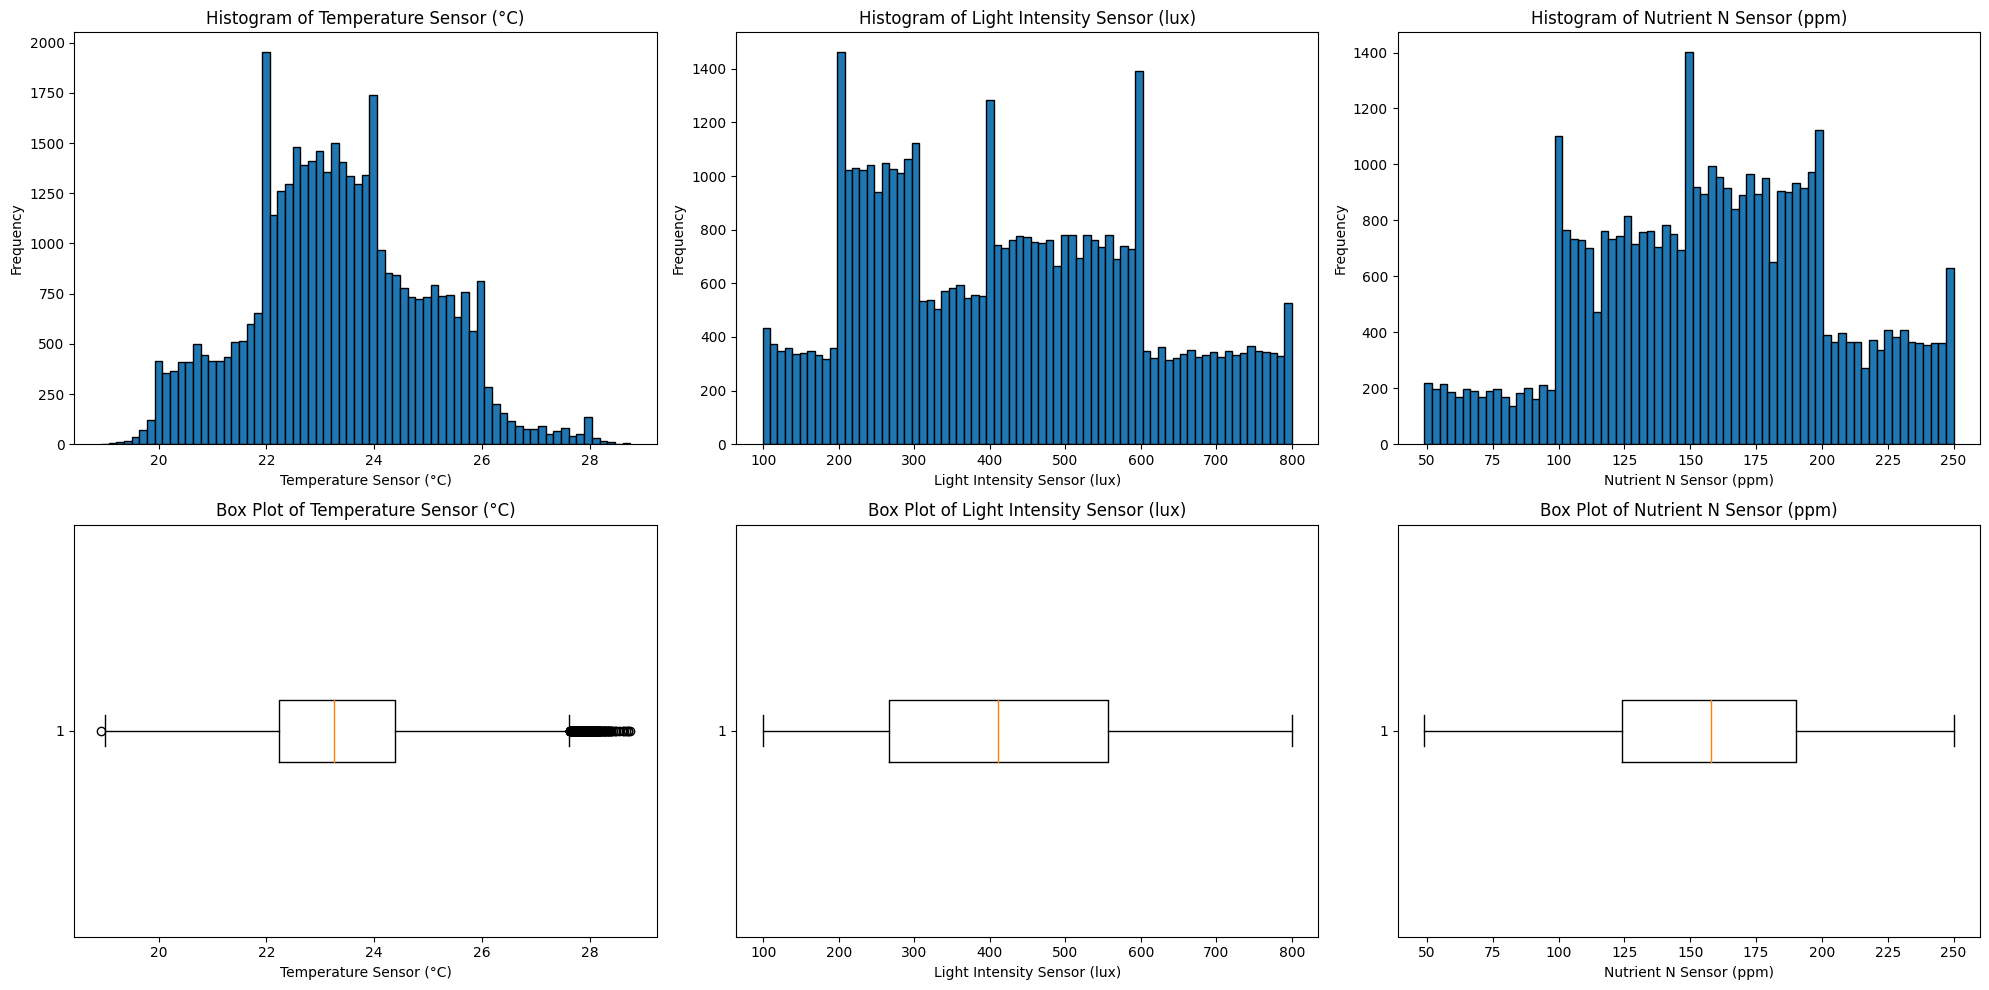

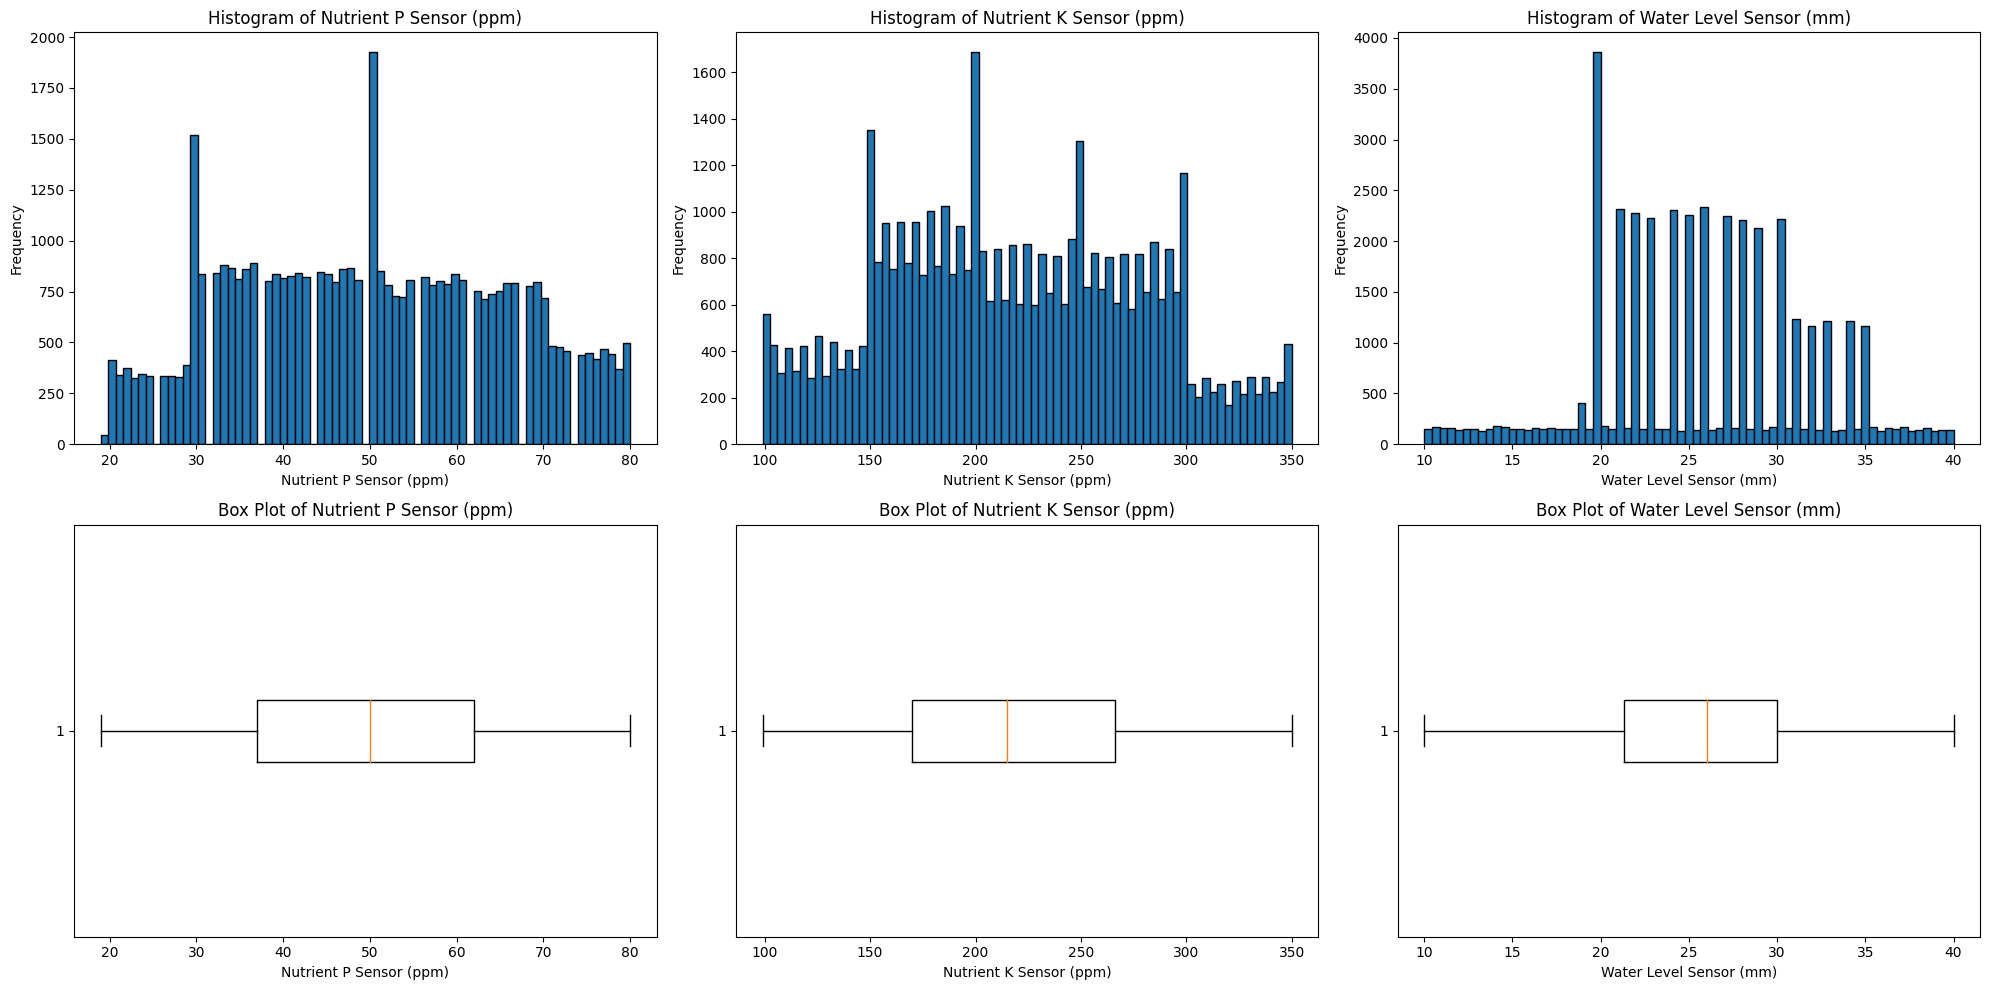

In [13]:
'''
We will need to deal with the other NaN values in the remaining columns.
We can either impute data or drop these rows.
To decide, we will look at the distribution of the data in these columns. (Histogram and Box Plot)
'''

import matplotlib.pyplot as plt
import numpy as np

null_cols = df.columns[df.isna().any()]
print("Columns with NaN values:", null_cols)

cols_per_plot = 3

num_plots = int(np.ceil(len(null_cols) / cols_per_plot))

for plot_idx in range(num_plots):
    fig, axes = plt.subplots(2, cols_per_plot, figsize=(20, 10))
    
    for i in range(cols_per_plot):
        col_idx = plot_idx * cols_per_plot + i
        if col_idx >= len(null_cols):
            break
        col = null_cols[col_idx]
        
        # Histogram
        ## We will choose the best number of bins using Rice criterion to produce a good distribution in the histogram.
        ## Use total number of non-null points for Rice criterion
        n_points = len(df[col].dropna())
        ## Apply the Rice criterion: number of bins = ceil(2 * n^(1/3))
        bins = int(np.ceil(2 * (n_points ** (1/3))))
        axes[0, i].hist(df[col].dropna(), bins=bins, edgecolor='black')
        axes[0, i].set_title(f'Histogram of {col}')
        axes[0, i].set_xlabel(col)
        axes[0, i].set_ylabel('Frequency')
        
        # Box Plot
        axes[1, i].boxplot(df[col].dropna(), vert=False)
        axes[1, i].set_title(f'Box Plot of {col}')
        axes[1, i].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [14]:
'''
From the histograms and box plots, we can see that the data in the columns 'Temperature Sensor (°C)', 'Nutrient N Sensor (ppm)', 
'Nutrient P Sensor (ppm)', and 'Water Level Sensor (mm)' are normally distributed.
Histograms of a normal distribution are usually bell-shaped, with only one peak, and is symmetric around the mean.
Box plots of a normal distribution shows a symmetrical box with whiskers of similar length and the median (the line inside the box) roughly in the center.
To confirm this, we can use in the in-built df.describe to see if the mean and median are nearly equal (an indicator of normal dist.).
'''

display(df[null_cols].describe())

,Temperature Sensor (°C),Light Intensity Sensor (lux),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),Water Level Sensor (mm)
count,40350.000000,44134.000000,39458.000000,43018.000000,44682.000000,40585.000000
mean,23.334741,420.080754,157.842237,49.879492,218.110626,25.722274
std,1.617147,178.500503,45.666572,15.414641,60.754634,5.826803
min,18.930000,99.000000,49.000000,19.000000,99.000000,10.001955
25%,22.232500,266.000000,124.000000,37.000000,170.000000,21.322871
50%,23.260000,411.000000,158.000000,50.000000,215.000000,26.000000
75%,24.390000,557.000000,190.000000,62.000000,266.000000,30.000000
max,28.750000,800.000000,250.000000,80.000000,350.000000,39.998717


In [15]:
'''
Comparing the mean and median (50%), we can see that the data in the columns 'Temperature Sensor (°C)', 'Nutrient N Sensor (ppm)', 
'Nutrient P Sensor (ppm)', and 'Water Level Sensor (mm)' are indeed normally distributed.
We can use the mean to impute the NaN values in these columns as
such a mean imputation can work effectively without significantly distorting the overall data distribution.
'''

mean_impute_cols = [
    'Temperature Sensor (°C)',
    'Nutrient N Sensor (ppm)',
    'Nutrient P Sensor (ppm)',
    'Water Level Sensor (mm)'
]

for col in mean_impute_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [16]:
'''
For the remaining non-normal distributed data, we can use a median imputation as
the median is not as sensitive to outliers and skewed data. 
It provides a more robust estimate of central tendency when the data is not normally distributed.
'''

median_impute_cols = [
    'Light Intensity Sensor (lux)',
    'Nutrient K Sensor (ppm)',
]

for col in median_impute_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [17]:
'''
From the output, we know our imputation and removal is successful!
'''

print("% of NaN values per column: (after imputation or removal)")
print(df.isna().sum() / df.shape[0] * 100)

% of NaN values per column: (after imputation or removal)
System Location Code            0.0
Previous Cycle Plant Type       0.0
Plant Type                      0.0
Plant Stage                     0.0
Temperature Sensor (°C)         0.0
Light Intensity Sensor (lux)    0.0
CO2 Sensor (ppm)                0.0
EC Sensor (dS/m)                0.0
O2 Sensor (ppm)                 0.0
Nutrient N Sensor (ppm)         0.0
Nutrient P Sensor (ppm)         0.0
Nutrient K Sensor (ppm)         0.0
pH Sensor                       0.0
Water Level Sensor (mm)         0.0
dtype: float64


### 3.3. Removing outliers

Box Plots before outlier removal:


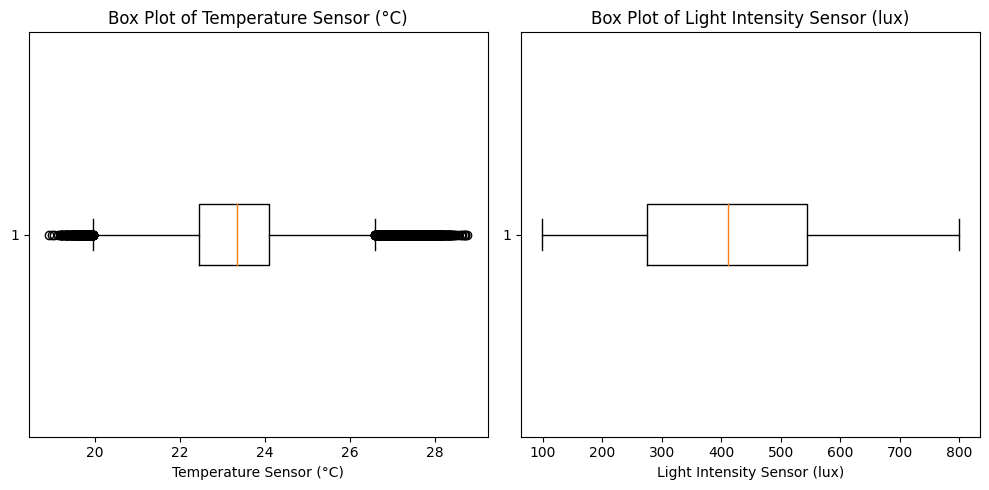

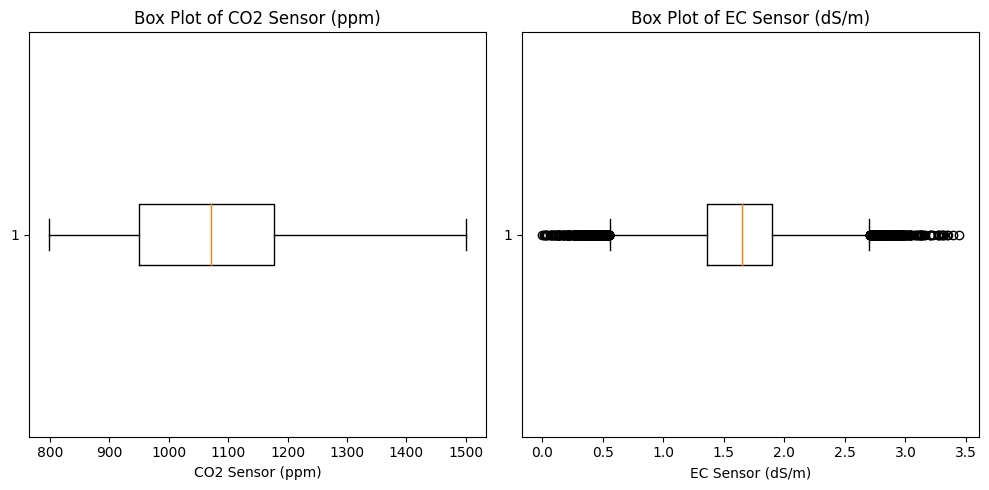

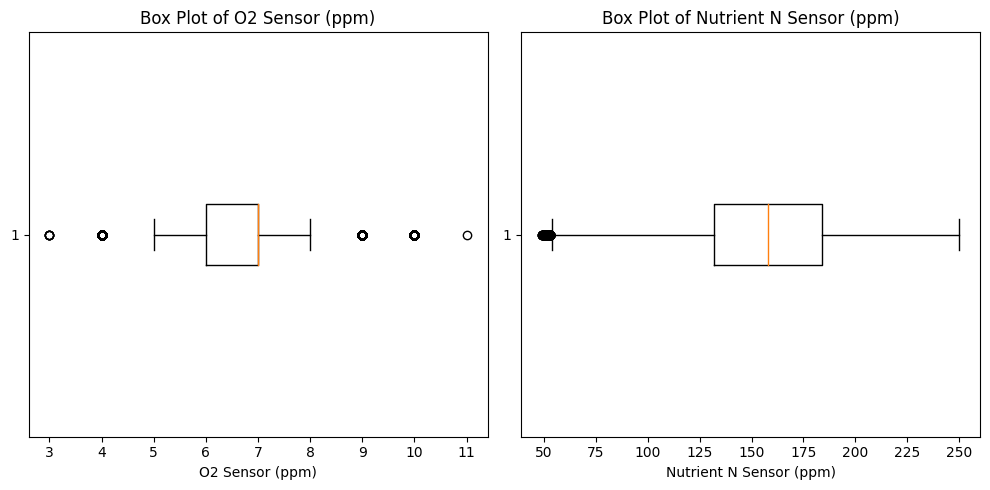

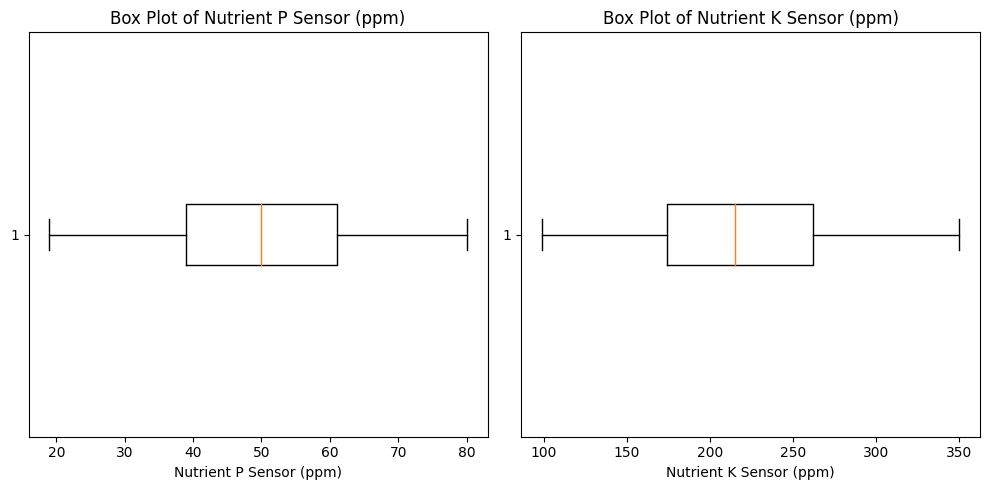

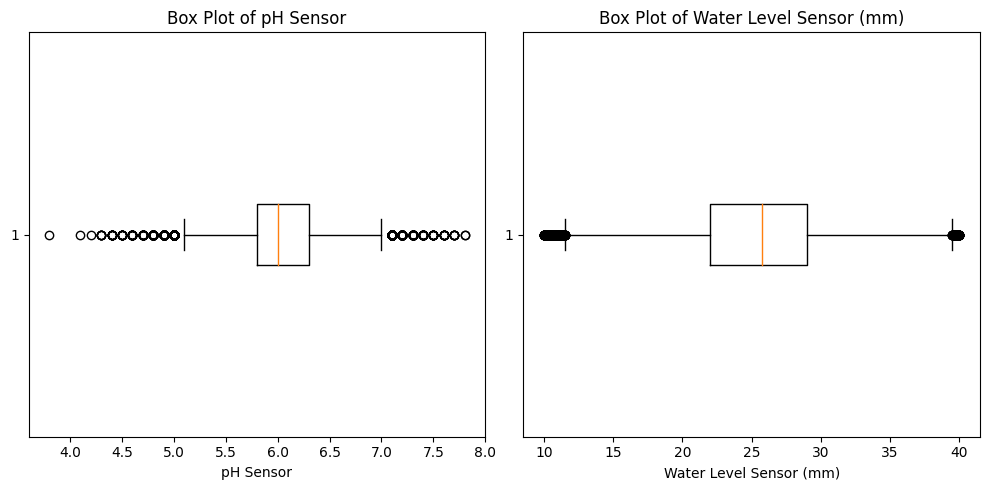

In [18]:
'''
Outliers, deviating significantly from the norm, can distort measures of central tendency and affect statistical analyses.
To deal with outliers, we need to view the box plots in greater detail.
We will then use the IQR method to identify and remove outliers.
'''

print("Box Plots before outlier removal:")

cols_per_plot = 2

num_plots = int(np.ceil(len(numeric_cols) / cols_per_plot))

for plot_idx in range(num_plots):
    fig, axes = plt.subplots(1, cols_per_plot, figsize=(10, 5))
    
    for i in range(cols_per_plot):
        col_idx = plot_idx * cols_per_plot + i
        if col_idx >= len(numeric_cols):
            break
        col = numeric_cols[col_idx]
        
        # Box Plot
        axes[i].boxplot(df[col].dropna(), vert=False)
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

Box Plots after outlier removal:


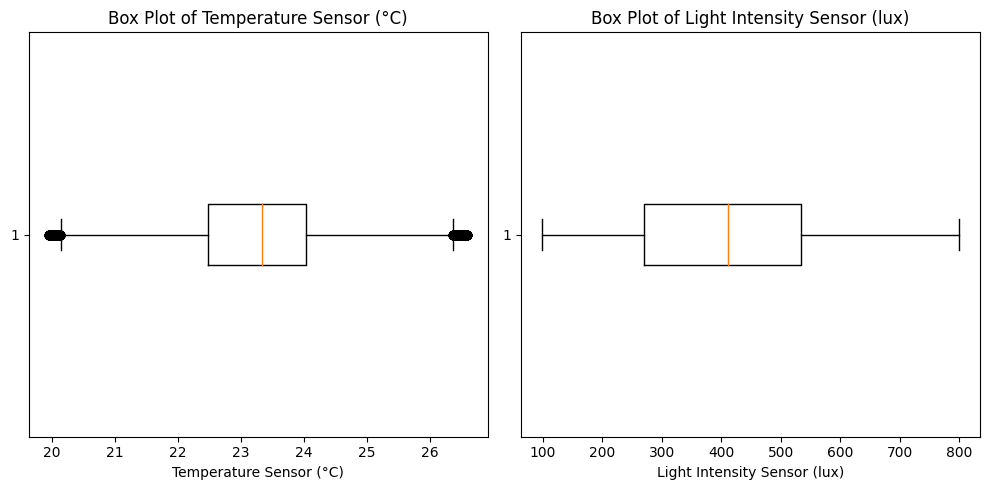

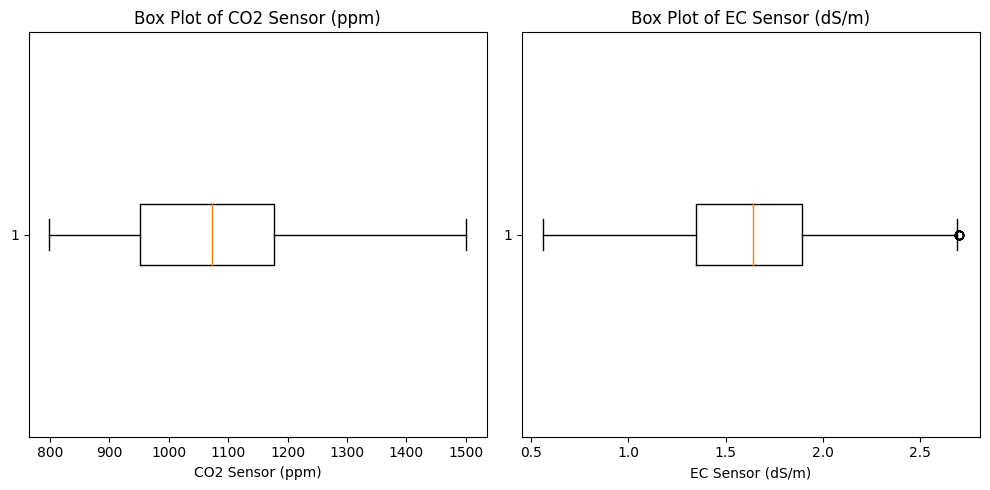

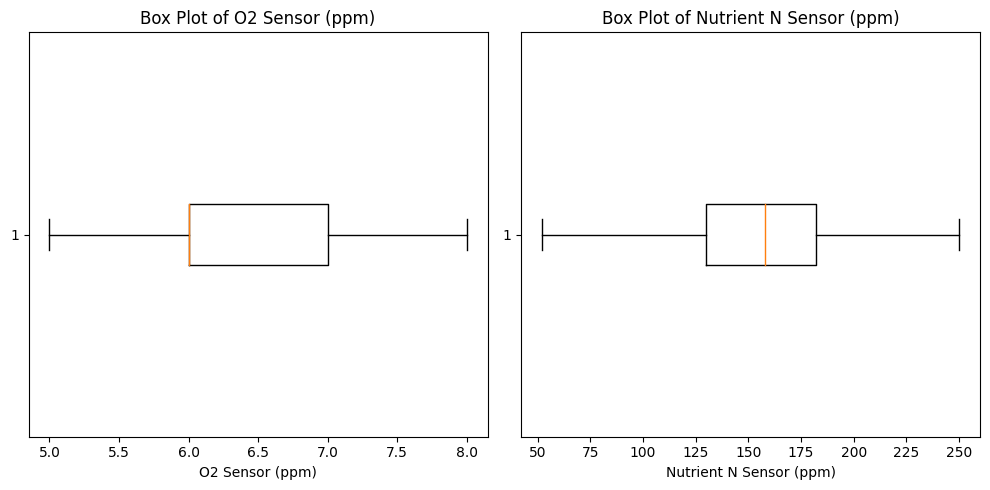

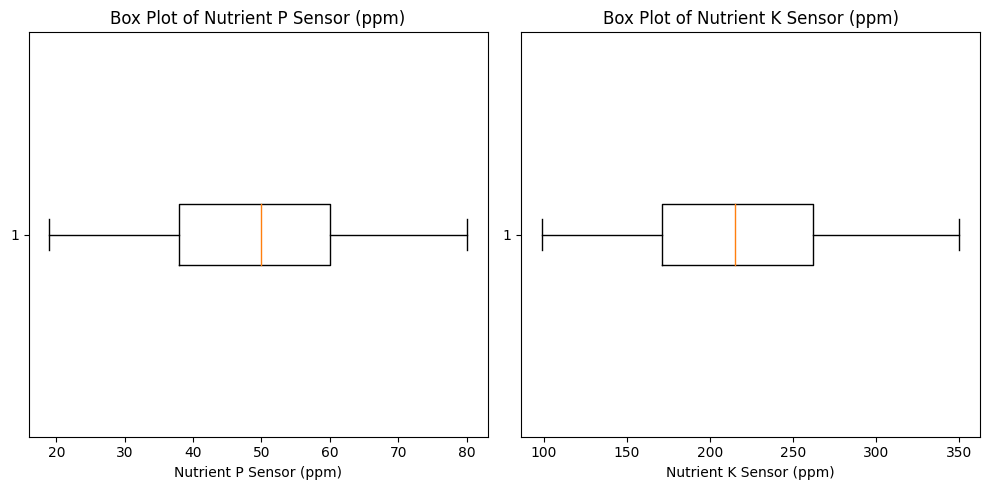

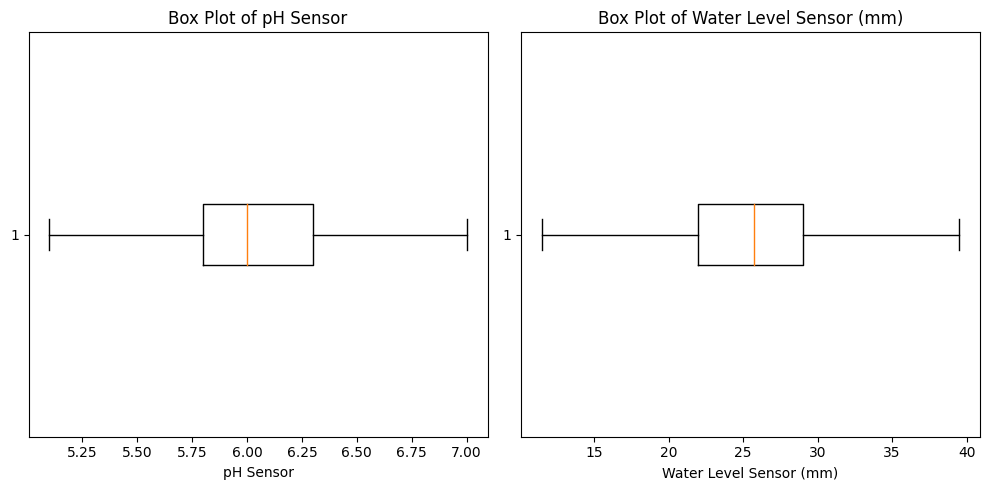

In [19]:
'''
From this output, we can confirm the outliers are removed!
'''

# Remove outliers using the IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Box Plots after outlier removal:")

cols_per_plot = 2

num_plots = int(np.ceil(len(numeric_cols) / cols_per_plot))

for plot_idx in range(num_plots):
    fig, axes = plt.subplots(1, cols_per_plot, figsize=(10, 5))
    
    for i in range(cols_per_plot):
        col_idx = plot_idx * cols_per_plot + i
        if col_idx >= len(numeric_cols):
            break
        col = numeric_cols[col_idx]
        
        # Box Plot
        axes[i].boxplot(df[col].dropna(), vert=False)
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

### 3.4. Ensuring proper category names and distribution in Categorical columns

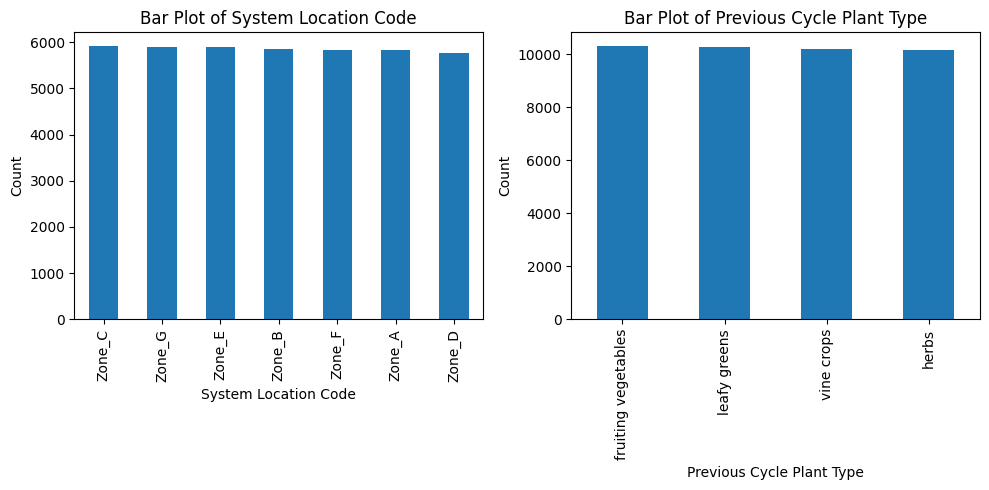

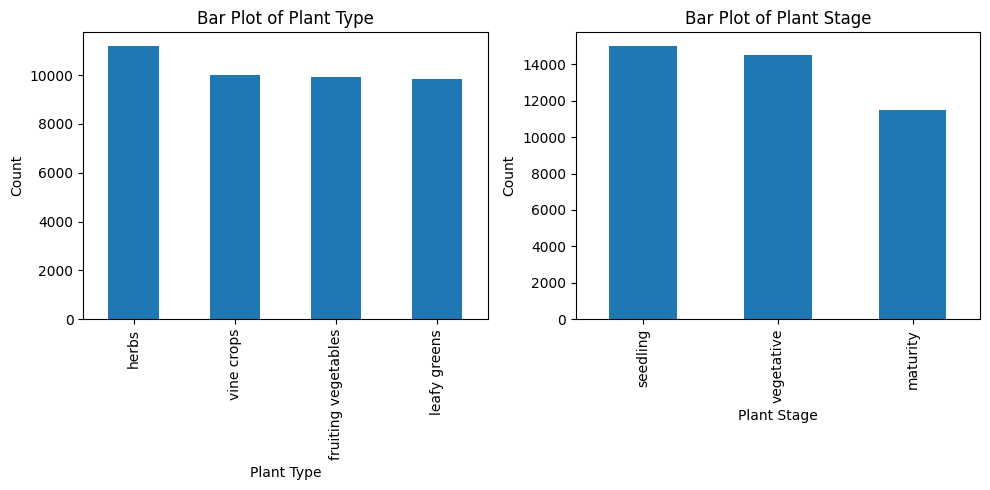

In [20]:
'''
From the output of the bar plots, we observe that the categorical data does not contain any unusual category names.
The data distribution across categories is fairly even, indicating no significant skewness.
'''

cols_per_plot = 2

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

num_plots = int(np.ceil(len(categorical_cols) / cols_per_plot))

for plot_idx in range(num_plots):
    fig, axes = plt.subplots(1, cols_per_plot, figsize=(10, 5))
    
    for i in range(cols_per_plot):
        col_idx = plot_idx * cols_per_plot + i
        if col_idx >= len(categorical_cols):
            break
        col = categorical_cols[col_idx]
        
        # Bar Plot
        df[col].value_counts().plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Bar Plot of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

### 3.5. Ensuring clarity of data when analysing

In [21]:
'''
The names of the columns are very long and not very direct.
We will rename the columns to make them more concise and easier to understand.
'''

# Rename columns
df = df.rename(columns={
    'Previous Cycle Plant Type': 'Previous Plant Type',
    'Temperature Sensor (°C)': 'Temperature (°C)',
    'Light Intensity Sensor (lux)': 'Light Intensity (lux)',
    'CO2 Sensor (ppm)': 'CO2 (ppm)',
    'EC Sensor (dS/m)': 'EC (dS/m)',
    'O2 Sensor (ppm)': 'O2 (ppm)',
    'Nutrient N Sensor (ppm)': 'Nitrogen (ppm)',
    'Nutrient P Sensor (ppm)': 'Phosphorus (ppm)',
    'Nutrient K Sensor (ppm)': 'Potassium (ppm)',
    'pH Sensor': 'pH',
    'Water Level Sensor (mm)': 'Water Level (mm)'
})

In [22]:
'''
We will reindex the columns based on logical order.
This will make it easier to read and interpret the data.
'''

# Reindex columns based on logical order
new_order = [
    # Essential Plant Information
    'System Location Code',
    'Plant Type',
    'Plant Stage',

    # Additional Plant Information
    'Previous Plant Type',
    
    # Environmental Conditions
    'Temperature (°C)',
    'Light Intensity (lux)',
    'CO2 (ppm)',
    'O2 (ppm)',
    'EC (dS/m)',
    
    # Nutrient Measurements
    'Nitrogen (ppm)',
    'Phosphorus (ppm)',
    'Potassium (ppm)',
    
    # Water Measurement
    'Water Level (mm)',
    'pH'
]

df = df.reindex(columns=new_order)

In [23]:
'''
Fianlly, we will sort the rows to see the relationships between the data.
'''

# Sort rows to see data relationships
df = df.sort_values(by=['System Location Code', 'Plant Type', 'Plant Stage', 'Previous Plant Type']).reset_index(drop=True)

display(df)

,System Location Code,Plant Type,Plant Stage,Previous Plant Type,Temperature (°C),Light Intensity (lux),CO2 (ppm),O2 (ppm),EC (dS/m),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),Water Level (mm),pH
0,Zone_A,fruiting vegetables,maturity,fruiting vegetables,26.070000,738.0,1086,8,1.86,157.842237,55.000000,236.0,13.753388,6.5
1,Zone_A,fruiting vegetables,maturity,fruiting vegetables,24.630000,628.0,1286,6,2.40,177.000000,66.000000,200.0,30.654430,6.3
2,Zone_A,fruiting vegetables,maturity,fruiting vegetables,26.580000,411.0,1028,6,1.92,200.000000,49.879492,210.0,30.597656,5.5
3,Zone_A,fruiting vegetables,maturity,fruiting vegetables,23.334741,609.0,1422,8,1.30,178.000000,67.000000,285.0,25.722274,6.2
4,Zone_A,fruiting vegetables,maturity,fruiting vegetables,25.950000,602.0,1150,8,1.76,224.000000,55.000000,230.0,25.722274,6.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40971,Zone_G,vine crops,vegetative,vine crops,23.334741,500.0,932,7,1.89,174.000000,55.000000,186.0,29.000000,5.8
40972,Zone_G,vine crops,vegetative,vine crops,23.334741,593.0,889,6,1.18,184.000000,65.000000,241.0,20.000000,5.5
40973,Zone_G,vine crops,vegetative,vine crops,23.334741,574.0,931,7,1.26,185.000000,49.879492,232.0,34.429043,5.9
40974,Zone_G,vine crops,vegetative,vine crops,25.620000,419.0,892,5,1.12,173.000000,58.000000,250.0,29.000000,5.4


## 4. Initial Data Inspection

In this step, we obtain the high-level summary of the clean dataset we just obtained. (This step is also to ensure our data is properly clean and processed properly beforehand.)

In [24]:
# Preview the Dataset Structure
## 1. Check the shape of dataset (rows, columns)
print("DataFrame shape:", df.shape)

print("-" * 50)

## 2. View data types and other info
print("DataFrame info:")
df.info()

DataFrame shape: (40976, 14)
--------------------------------------------------
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40976 entries, 0 to 40975
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   System Location Code   40976 non-null  object 
 1   Plant Type             40976 non-null  object 
 2   Plant Stage            40976 non-null  object 
 3   Previous Plant Type    40976 non-null  object 
 4   Temperature (°C)       40976 non-null  float64
 5   Light Intensity (lux)  40976 non-null  float64
 6   CO2 (ppm)              40976 non-null  int64  
 7   O2 (ppm)               40976 non-null  int64  
 8   EC (dS/m)              40976 non-null  float64
 9   Nitrogen (ppm)         40976 non-null  float64
 10  Phosphorus (ppm)       40976 non-null  float64
 11  Potassium (ppm)        40976 non-null  float64
 12  Water Level (mm)       40976 non-null  float64
 13  pH        

In [25]:
# High-level overview of Dataset
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
display(df[categorical_cols].describe())

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
display(df[numeric_cols].describe())

,System Location Code,Plant Type,Plant Stage,Previous Plant Type
count,40976,40976,40976,40976
unique,7,4,3,4
top,Zone_C,herbs,seedling,fruiting vegetables
freq,5918,11191,14998,10314


,Temperature (°C),Light Intensity (lux),CO2 (ppm),O2 (ppm),EC (dS/m),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),Water Level (mm),pH
count,40976.000000,40976.000000,40976.000000,40976.000000,40976.000000,40976.000000,40976.000000,40976.000000,40976.000000,40976.000000
mean,23.306822,412.718616,1082.699580,6.456414,1.620094,156.858875,49.470132,216.604085,25.840990,6.023121
std,1.356349,168.585581,171.025188,0.922158,0.391397,41.282847,14.622010,59.724757,4.962589,0.371125
min,19.960000,99.000000,799.000000,5.000000,0.560000,52.000000,19.000000,99.000000,11.500441,5.100000
25%,22.480000,270.000000,952.000000,6.000000,1.350000,130.000000,38.000000,171.000000,22.000000,5.800000
50%,23.334741,411.000000,1072.000000,6.000000,1.640000,157.842237,49.879492,215.000000,25.722274,6.000000
75%,24.040000,535.000000,1177.000000,7.000000,1.890000,182.000000,60.000000,262.000000,29.000000,6.300000
max,26.590000,800.000000,1500.000000,8.000000,2.700000,250.000000,80.000000,350.000000,39.497515,7.000000


## 5. Bivariate/Multivariate Analysis

This step is the juicy part where we start to analyse relationships among features, particularly those that might influence Temperature and the combined Plant Type-Stage classification. (as per our Problem Statement)

### 5.1. Temperature vs other features

#### 5.1.1. vs Numeric Features

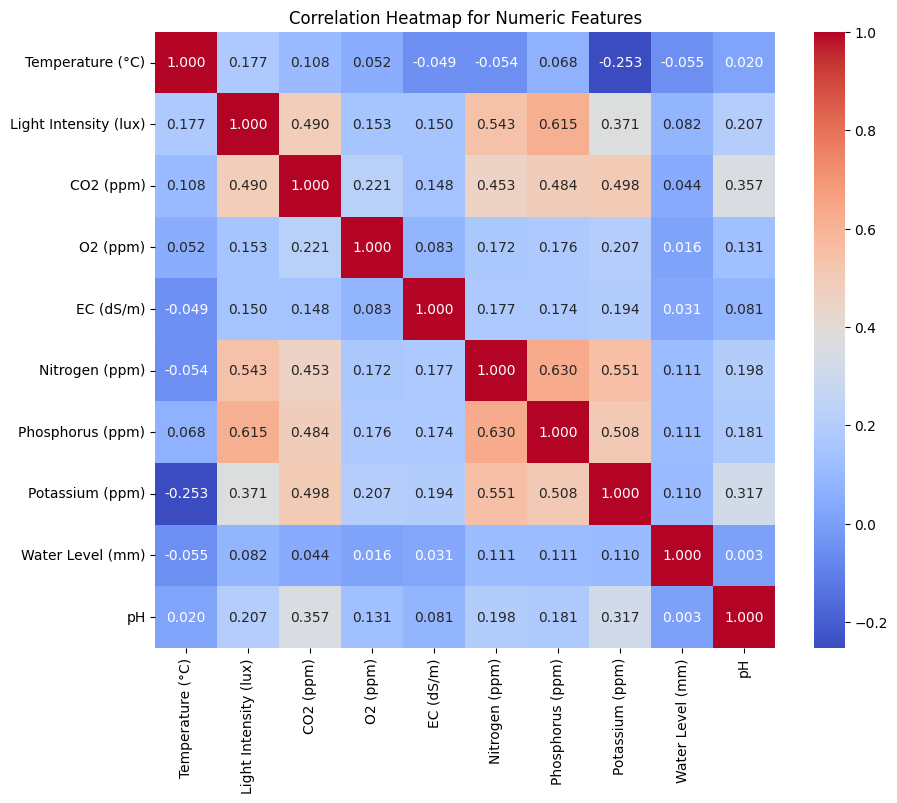

In [26]:
'''
A correlation matrix is a table showing correlation coefficients between variables.
In this case, we want to see the first row to see how Temperature correlates with other variables.
'''

import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

##### Observation:
The correlations between Temperature and other features are rather low.
The 3 most significant correlations (+- >0.100) are:
1. CO2 (ppm) at 0.108
2. Light intensity (lux) at 0.177
3. Potassium (ppm) at -0.253

We will definitely look into these 3 via scatter plots to map out the relationships.

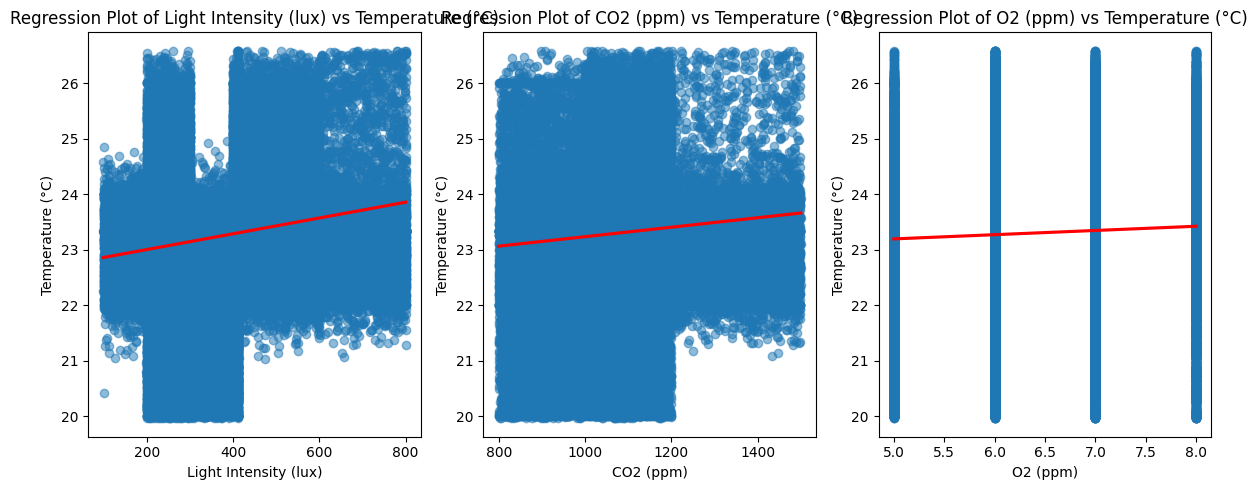

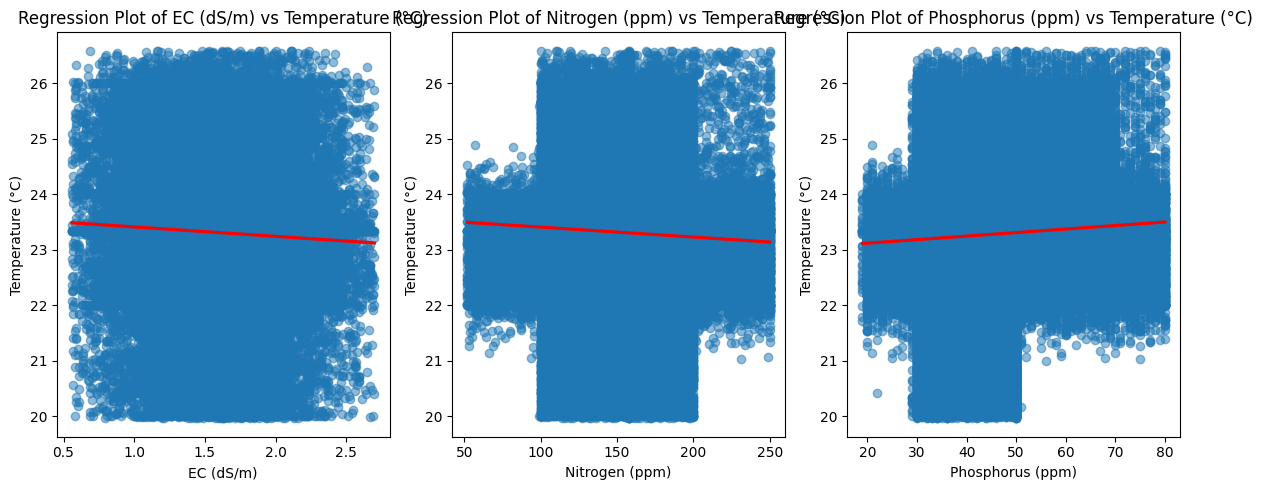

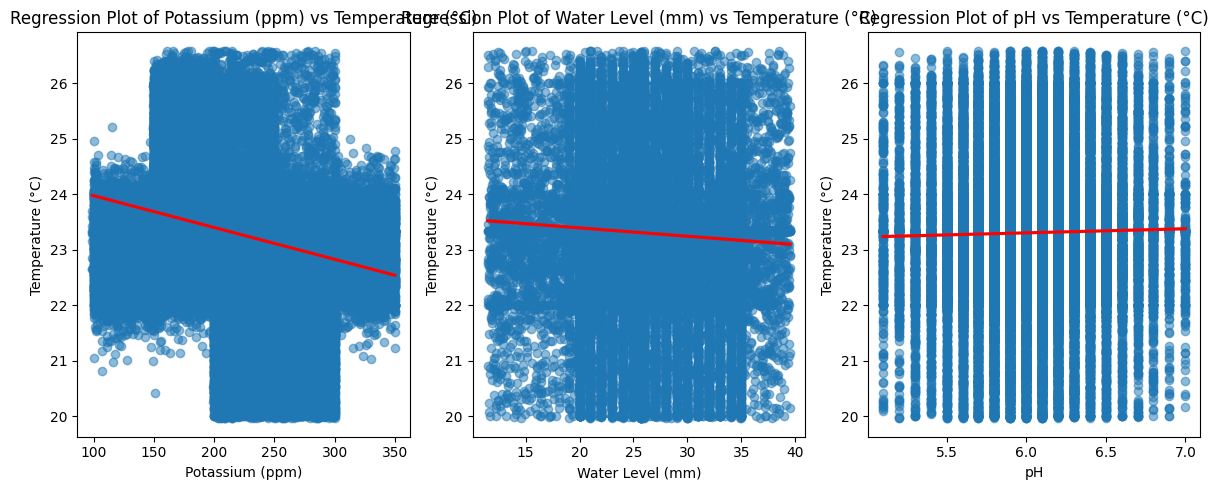

In [27]:
'''
We will then plot regression scatter plots to see the relationship between Temperature and other variables.
'''

test_cols = numeric_cols.drop('Temperature (°C)')
target_col = 'Temperature (°C)'

cols_per_plot = 3
num_plots = int(np.ceil(len(test_cols) / cols_per_plot))

for plot_idx in range(num_plots):
    fig, axes = plt.subplots(1, cols_per_plot, figsize=(12, 5))

    for i in range(cols_per_plot):
        col_idx = plot_idx * cols_per_plot + i
        if col_idx >= len(test_cols):
            break
        col = test_cols[col_idx]

        # Regression Scatter Plot
        sns.regplot(x=df[col], y=df[target_col], ax=axes[i], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
        axes[i].set_title(f'Regression Plot of {col} vs {target_col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_col)

    plt.tight_layout()
    plt.show()

##### Observation:
From the scatter plots, I conclude:

1. Light Intensity (lux) vs. Temperature
The regression line has a slight positive slope. However, the data is very scattered around the regression line.
    - Conclusion: Weak linear relationship?

2. CO2 (ppm) vs. Temperature
The regression line has a slight positive slope, indicating a weak positive correlation. However, the data is also widely spread.
    - Conclusion: Weak linear relationship?

3. Potassium (ppm) vs. Temperature
The red line has a noticeable negative slope. The data shows significant spread is clearer, compared to the other features.
    - Conclusion: Moderate linear relationship.

^ These 3 are also mentioned in the correlation matrix as possible predictors, supporting our above suspicions.

4. The rest
Regression line is flat with no clear trend. The scatter plot shows even spread.
    - Conclusion: No significant linear or non-linear relationship.

Moving on, we will definitely use Potassium (ppm) as a strong predictor.

#### 5.1.2. vs Categorical Features

In [28]:
'''
To deal with Categorical Features, we can conduct a one-way ANOVA test.
This statistical test helps us determine if there are significant differences between our categorical independent variables and the dependent variable ("Temperature (°C)").
We will obtain:
- F-value: This value compares the variance between groups to the variance within groups. A higher F-value suggests that the group means differ more relative to the variability within the groups, indicating a stronger potential effect.
- p-value: This value represents the probability of obtaining the observed results (or more extreme) if there were no actual differences between the groups. A p-value below 0.05 indicates that the observed differences are statistically significant, meaning it is unlikely they occurred by random chance.
'''

import scipy.stats as stats

tested_cols = categorical_cols

for col in tested_cols:
	groups = [df['Temperature (°C)'][df[col] == category] for category in df[col].unique()]
	f_val, p_val = stats.f_oneway(*groups)
	print(f"ANOVA results for {col}:")
	print(f"F-value: {f_val}")
	print(f"P-value: {p_val}")
	print("-" * 50)

ANOVA results for System Location Code:
F-value: 1.545099194607209
P-value: 0.15895320935562887
--------------------------------------------------
ANOVA results for Plant Type:
F-value: 5882.662433979373
P-value: 0.0
--------------------------------------------------
ANOVA results for Plant Stage:
F-value: 2819.122132532617
P-value: 0.0
--------------------------------------------------
ANOVA results for Previous Plant Type:
F-value: 1.7622247924000312
P-value: 0.15198745351388437
--------------------------------------------------


##### Observation:
From the ANOVA results, I conclude:

1. Plant Type:
The F-value is very high with a p-value equal to 0.0.
This indicates a highly significant effect, meaning that temperature differences across the different Plant Type-Stage groups are statistically significant.

1. Plant Stage:
The F-value is high with a p-value equal to 0.0.
This indicates a significant effect, meaning that temperature differences across the different Plant Type-Stage groups are statistically significant.

3. System Location Code & Previous Plant Type:
The F-value is low with a p-value > 0.05.
This suggests that there is no statistically significant difference in temperature across the different groups.

Moving on, we will use Plant Type and Plant Stage as predictors.

### 5.2. Plant Type-Stage vs sensor data

In [29]:
'''
To start off, we need to combine Plant Type and Plant Stage to create a new column called Plant Type-Stage.
'''

df['Plant Type-Stage'] = df['Plant Type'] + '-' + df['Plant Stage']

In [30]:
'''
To ensure the stage order is easy to read, we manually set the order of the stages.
'''

plant_type_stage_order = [
    'fruiting vegetables-seedling',
    'fruiting vegetables-vegetative',
    'fruiting vegetables-maturity',
    'herbs-seedling',
    'herbs-vegetative',
    'herbs-maturity',
    'leafy greens-seedling',
    'leafy greens-vegetative',
    'leafy greens-maturity',
    'vine crops-seedling',
    'vine crops-vegetative',
    'vine crops-maturity',
]

C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)
C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)


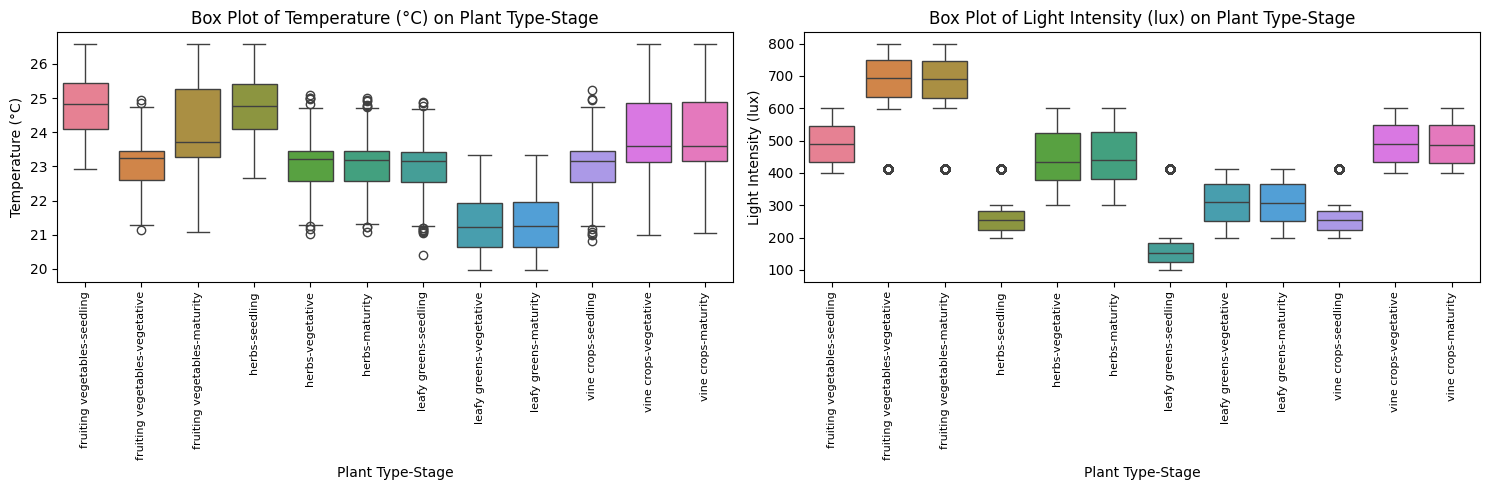

C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)
C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)


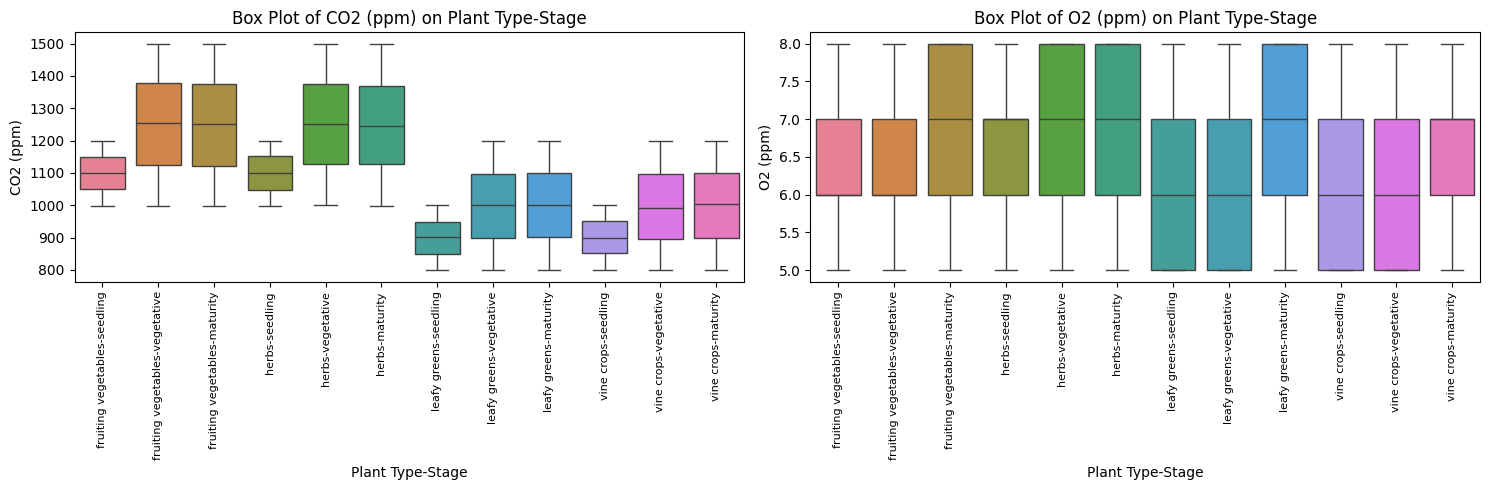

C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)
C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)


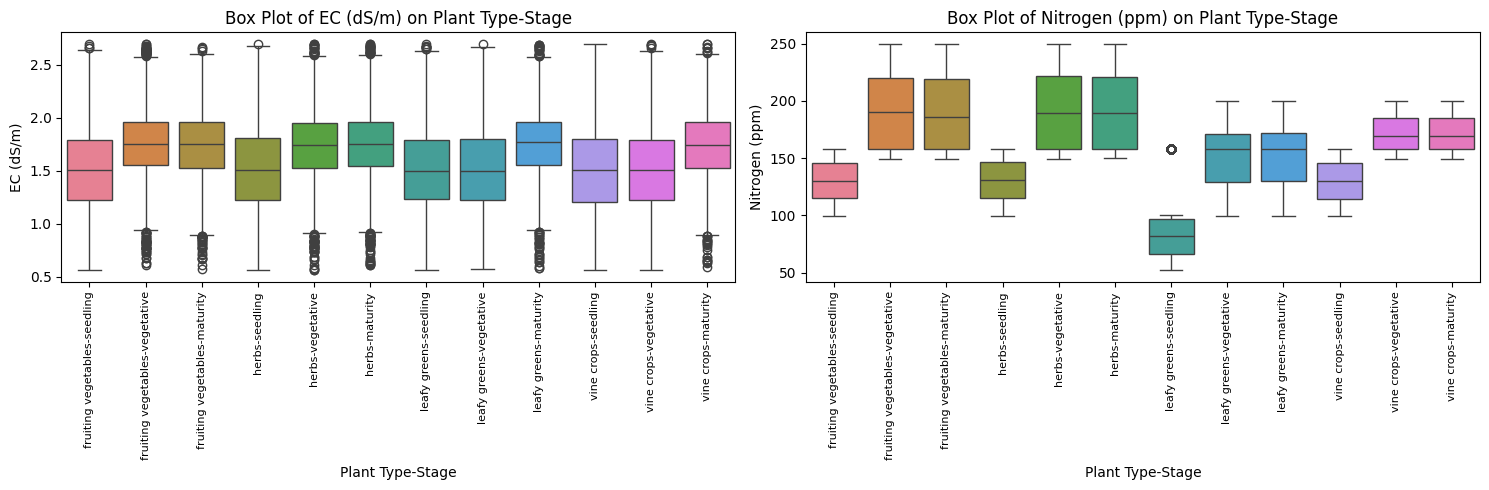

C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)
C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)


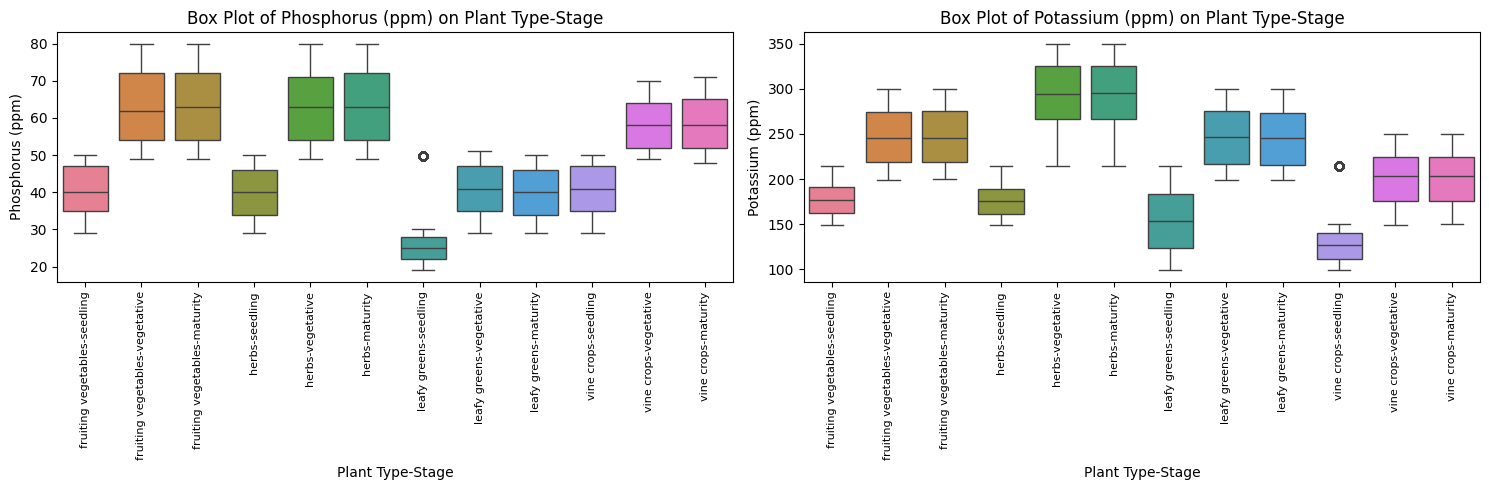

C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)
C:\Users\tanhu\AppData\Local\Temp\ipykernel_90580\3675364062.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(categories, rotation=90)


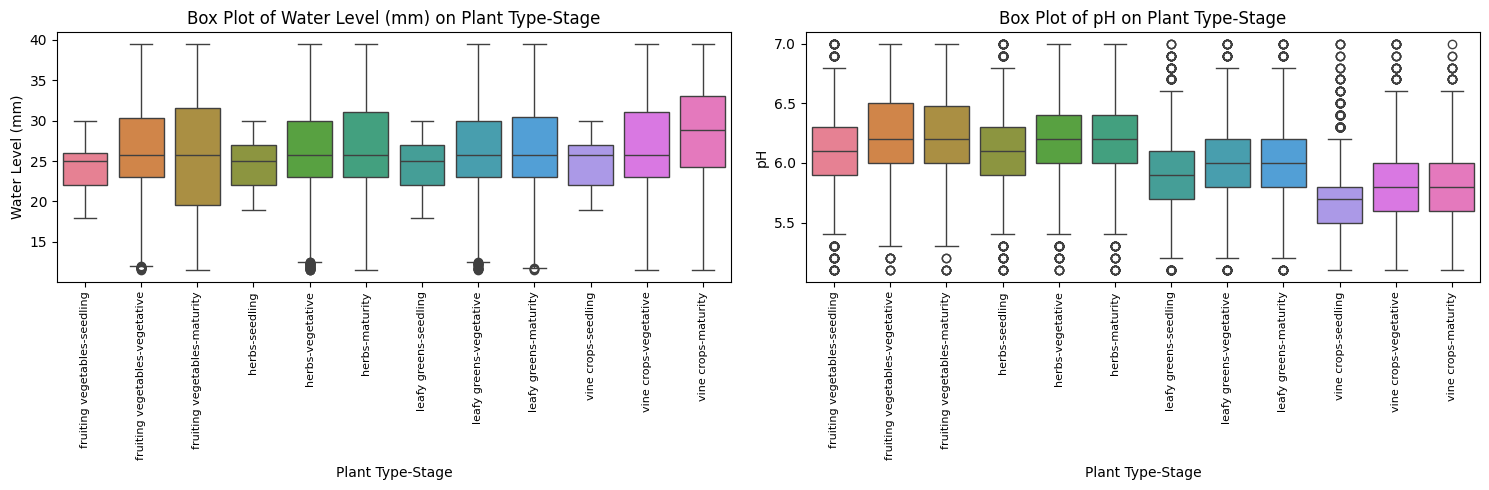

In [31]:
'''
We will then plot box plots to see the distribution of the numeric columns across the Plant Type-Stage.
'''

cols_per_plot = 2
num_plots = int(np.ceil(len(numeric_cols) / cols_per_plot))

for plot_idx in range(num_plots):
    fig, axes = plt.subplots(1, cols_per_plot, figsize=(15, 5))
    
    for i in range(cols_per_plot):
        col_idx = plot_idx * cols_per_plot + i
        if col_idx >= len(numeric_cols):
            break
        col = numeric_cols[col_idx]
        
        pts = df.groupby('Plant Type-Stage')[col].apply(list)
        
        pts = pts.reindex(plant_type_stage_order)
        
        categories = list(pts.index)
        
        # Vertical Box Plot
        sns.boxplot(data=list(pts), ax=axes[i])
        axes[i].set_title(f'Box Plot of {col} on Plant Type-Stage')
        axes[i].set_xlabel('Plant Type-Stage')
        axes[i].set_ylabel(col)
        axes[i].set_xticklabels(categories, rotation=90)
        axes[i].tick_params(axis='x', labelsize=8)
    
    plt.tight_layout()
    plt.show()

##### Observations:

We can use the boxes (without the whiskers) to see where the general bulk of data falls to compare against the other respective boxes in each plot.

- All plant types need more light as it progresses from seedling to vegetative but does not need more when going from vegetative to maturity.
Fruiting vegetables require the most light, followed by herbs and vine crops which require similar amount, and leafy greens need the least light.
- All plant types need more CO2 as it progresses from seedling to vegetative but does not need more when going from vegetative to maturity.
Fruiting vegetables and herbs require a similar amount and the most CO2 while leafy greens and vine crops require a less amount yet similar.
- Fruiting vegetables and herbs produce more EC as it progresses from seedling to vegetative but does not produce more when going from vegetative to maturity.
leafy greens and vine crops only start to produce more EC when going from vegetative to maturity.
- All plant types need more Nitrogen as it progresses from seedling to vegetative but does not need more when going from vegetative to maturity.
Fruiting vegetables and herbs require a similar amount and the most Nitrogen, followed by vine crops and then leafy greens.
- All plant types need more Phosphorus as it progresses from seedling to vegetative but does not need more when going from vegetative to maturity.
Fruiting vegetables and herbs require a similar amount and the most Phosphorus, followed by vine crops and then leafy greens.
- All plant types need more Potassium as it progresses from seedling to vegetative but does not need more when going from vegetative to maturity.
Herbs require the most Potassium, followed by Fruiting vegetables, leafy greens, and then vine crops.
- All plant types need more water as it progresses from seedling to vegetative and to maturity.
- All plant types increase pH as it progresses from seedling to vegetative but does not increase when going from vegetative to maturity.
- It is hard to tell the trends for Temperature and O2.

## 6. Overall Analysis:

1. w.r.t. predicting Tempature Conditions
    - Potassium is a decent predictor.
    - Plant Type is a great predictor.
    - Plant Stage is a great predictor.
    - All these 3 predictors can be used while the rest can be excluded.

2. w.r.t. combined "Plant Type-Stage" vs sensor data:
    - All plant types need more Light, CO2, nutrients (Nitrogen, Phosphorus, Potassium) as it progresses from seedling to vegetative but does not need more when going from vegetative to maturity.
    - More EC is produced as all plant types progress.
    - All plant types need more water as it progresses from seedling to vegetative and to maturity.
    - All plant types increase pH as it progresses from seedling to vegetative but does not increase when going from vegetative to maturity.